## Problem

### The Inefficiency of Manual Preprocessing

* **The Setup:** Multiple columns require different transformations (scaling, OHE, Ordinal encoding, etc.).
* **The Problem:** This creates different numpy arrays which have to be added together later, which is **inefficient**.

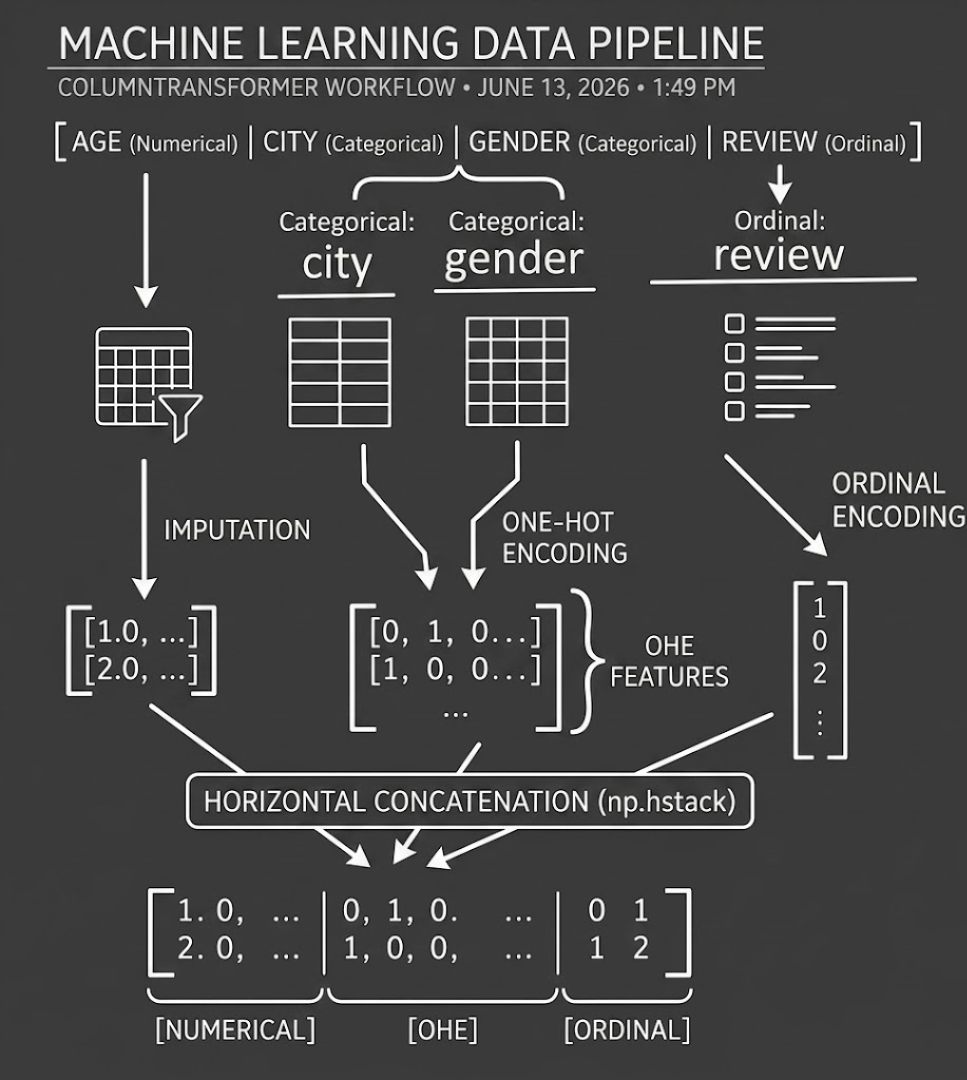

solution: use 'ColumnTransformer' class of 'sklearn' to do all this in a single line of code

## Common things

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('Covid_toy.csv')

In [26]:
df.sample(5)

,age,gender,fever,cough,city,has_covid
65,69,Female,102.0,Mild,Bangalore,No
39,50,Female,103.0,Mild,Kolkata,No
6,14,Male,101.0,Strong,Bangalore,No
31,83,Male,103.0,Mild,Kolkata,No
53,83,Male,98.0,Mild,Delhi,Yes


In [37]:
df['gender'].unique() #replace and see for others too: city, fever, cough

<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

In [7]:
df.isnull().sum()

age           0
gender        0
fever        10
cough         0
city          0
has_covid     0
dtype: int64

**'fever' has missing values so use "SimpleImputer" it will replace all missign values with mean vlaues**

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(df.drop(columns=['has_covid']),
                                                df['has_covid'],
                                                test_size=0.2,
                                                random_state=0)

# 1. **Normal method**

### Dealing with null vlaues in fever


In [61]:
from sklearn.impute import SimpleImputer
si = SimpleImputer()

X_train_fever = si.fit_transform(X_train[['fever']])
X_test_fever = si.fit_transform(X_test[['fever']])


### ordinal encoding of cough


In [34]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[['Mild','Strong']])

X_train_cough = oe.fit_transform(X_train[['cough']])
X_test_cough = oe.fit_transform(X_test[['cough']])

### OneHotEncoding - gender, city

In [58]:
from sklearn.preprocessing import OneHotEncoder

oe = OneHotEncoder(drop='first',sparse_output =False,dtype=int)

X_train_G_C = oe.fit_transform(X_train[['gender','city']])
X_test_G_C = oe.fit_transform(X_test[['gender','city']])

### Extract age 

In [72]:
X_train_age = X_train[['age']].values
X_test_age = X_test[['age']].values

## Finally concatinate every col to form df

In [77]:
X_train_transformed = np.concatenate((X_train_fever,X_train_cough,X_train_G_C,X_train_age),axis=1)
X_test_transformed = np.concatenate((X_test_fever,X_test_cough,X_test_G_C,X_test_age),axis=1)

In [81]:
X_train_transformed.shape

(80, 7)

# 2. <mark>**Better Method**</mark>

In [83]:
from sklearn.compose import ColumnTransformer

In [94]:
ct = ColumnTransformer(transformers=[
    ('tnf1',SimpleImputer(),['fever']),
    ('tnf2',OrdinalEncoder(categories=[['Mild','Strong']]),['cough']),
    ('tnf3',OneHotEncoder(drop='first',sparse_output=False),['gender','city'])
],remainder='passthrough') 

remainder: Columns which shouldn't be transformed.

'passthrough' = It should be as it is.

'drop' = Remove that column.

In [97]:
X_train_transformed1 = ct.fit_transform(X_train)

In [101]:
X_test_transformed1 = ct.transform(X_test)